In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


bib

In [ ]:
import os
import random
import shutil
import logging
import json
import cv2
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from pycocotools import mask as maskUtils
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
base = '/content/drive/MyDrive/thesis doc/FracAtlas'
images_fractured = os.path.join(base, 'images', 'Fractured')
IMAGES_DIR_NON_FRACTURED = os.path.join(base, 'images', 'Non_fractured')
ANNOTATION_FILE = os.path.join(base, 'Annotations', 'COCO JSON', 'COCO_fracture_masks.json')
CSV_FILE = os.path.join(base, 'dataset.csv')
OUTPUT_IMAGES_DIR = os.path.join(base, 'augmented(images_m_sup)')
OUTPUT_MASKS_DIR = os.path.join(base, 'augmented(mask_m_sup)')
CLEAN_OUTPUT = True #vide les anciens fichiers avant de recommencer (si les dossiers de sortie =true ---­> vider).
USE_THREADS = True #exécute le traitement en parallèle pour aller plus vite.
MAX_WORKERS = 8 #sur 8 workers
AUG_PER_IMAGE = 3 #3 augmentations par image originale.
SEED = 42 #Le SEED fixe le point de départ pour générer des nombres aléatoires afin que le programme produise toujours les mêmes résultats à chaque exécution.
random.seed(SEED)
np.random.seed(SEED)
##################################################################### LOGGING#######################################################################
# Sert a Crée un fichier preprocessing.log pour enregistrer les erreurs ou avertissements pendant le traitement (par ex. masque manquant, taille incorrecte...).
LOG_DIR = os.path.join(base, "logs")
os.makedirs(LOG_DIR, exist_ok=True)
logging.basicConfig(
    filename=os.path.join(LOG_DIR, "preprocessing.log"),#indique le fichier où seront enregistrés les messages (preprocessing.log).
    level=logging.INFO,#définit le niveau minimal des messages à enregistrer (INFO et plus graves, comme WARNING et ERROR).
    format="%(asctime)s [%(levelname)s] %(message)s"
)#définit le format de chaque message : %(asctime)s → la date et l’heure du message %(levelname)s → le niveau du message (INFO, WARNING…) %(message)s → le texte du message
def log_issue(img_file, message):#une fonction pour enregistrer rapidement un problème avec une image.
    logging.warning(f"{img_file} - {message}")#écrit un message de type WARNING dans le fichier de log, avec le nom du fichier et le message associé.
#################################################################### PREPARATION DOSSIERS###########################################################
def ensure_dir(d, clean=False):#Crée le dossier d s’il n’existe pas déjà.
    os.makedirs(d, exist_ok=True)#évite l’erreur si le dossier existe déjà.
    if clean:#Si l’option clean est activée (True), on supprime tout ce qui est à l’intérieur du dossier avant de l’utiliser.
        for f in os.listdir(d):#Parcourt tous les fichiers et sous-dossiers dans d.
            path = os.path.join(d, f)#Construit le chemin complet de l’élément f.
            try:#Essaie de supprimer chaque fichier ou dossier, et affiche un message d’erreur si la suppression échoue.
                if os.path.isfile(path):
                    os.remove(path)#Si l’élément est un fichier, il est supprimé.
                else:
                    shutil.rmtree(path, ignore_errors=True)#Si l’élément est un dossier, tout le dossier est supprimé avec son contenu.
            except Exception as e:
                print(f"Erreur suppression {path}: {e}")

ensure_dir(OUTPUT_IMAGES_DIR, clean=CLEAN_OUTPUT)#Prépare les dossiers pour les images et les masques.
ensure_dir(OUTPUT_MASKS_DIR, clean=CLEAN_OUTPUT)
#################################################################### CHARGER ANNOTATIONS COCO###########################################################
with open(ANNOTATION_FILE, 'r') as f:#Ouvre le fichier JSON ANNOTATION_FILE en lecture ('r').
    coco = json.load(f)#lit le contenu JSON et le transforme en dictionnaire Python/coco contient toutes les informations : images, annotations, catégories,...

annots_per_image = {}#Crée un dictionnaire vide annots_per_image.
for ann in coco['annotations']:
    annots_per_image.setdefault(ann['image_id'], []).append(ann)#setdefault ;crée une liste vide si l’ID de l’image n’existe pas encore dans le dictionnaire.//ajoute l’annotation à la liste de cette image.
    #annots_per_image[image_id] contient toutes les annotations associées à cette image.

basename_to_id = {}#Crée un dictionnaire basename_to_id/Il servira à associer le nom de l’image (sans extension) à son ID unique dans le fichier COCO ex:{ "img0001": 123, "img0002": 124 }
for img in coco['images']:
    stem = os.path.splitext(img['file_name'])[0].lower()#.lower() convertit le nom en minuscules pour éviter les problèmes de casse ("Img0001" = "img0001")./splitext:Supprime l’extension (.png, .jpg, etc.) du nom de fichier.
    basename_to_id[stem] = img['id']#clé :val/"img0001": 123,
    #Ce bloc de code crée un dictionnaire qui permet de retrouver rapidement l’ID d’une image à partir de son nom de fichier, ce qui est très pratique pour accéder aux annotations correspondantes.
############################################################### FILTRAGE MEMBRE SUPÉRIEUR FRACTURÉ########################################################
df = pd.read_csv(CSV_FILE)#lit le fichier CSV et le transforme en DataFrame df
################################################################ Assurer que 'image_id' est cohérent#####################################################
df['image_id_norm'] = df['image_id'].str.lower().str.replace(r'\.png|\.jpg|\.jpeg', '', regex=True)#: crée une nouvelle colonne où : le nom des images est en minuscules (lower())/l’extension est supprimée (.png, .jpg, .jpeg)

########################################################### Filtrage main/épaule, jambe/hanche=0, fracturé=1##############################################
upper_limb_fractured = df[#condition de filtrage
    ((df['hand']==1) | (df['shoulder']==1)) &
    ((df['leg']==0) & (df['hip']==0)) &
    (df['fractured']==1)
]

upper_limb_images = set(upper_limb_fractured['image_id_norm'].tolist())#lister

def is_upper_limb_fractured(img_file):
    stem = os.path.splitext(os.path.basename(img_file))[0].lower()
    return stem in upper_limb_images#Fonction qui vérifie si une image donnée fait partie de ce filtrage
############################################################### UTILITAIRES###################################################################################
def harmonize_mask(mask):
    return np.where(mask>127,255,0).astype(np.uint8)#Transforme le masque en binaire : 0 ou 255 (noir/blanc).

def check_mask_size(mask, img_shape, img_file):#Vérifier la taille du masque
    if mask.shape[:2] != img_shape[:2]:
        log_issue(img_file, f"Taille masque {mask.shape[:2]} != taille image {img_shape[:2]}")
        mask = cv2.resize(mask, (img_shape[1], img_shape[0]), interpolation=cv2.INTER_NEAREST)#Si le masque et l’image n’ont pas la même taille, on redimensionne le masque.
    return mask
def augment_once(img, mask):#Augmentation d’une image
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
        mask = cv2.flip(mask, 1)
    if random.random() < 0.3:
        img = cv2.flip(img, 0)
        mask = cv2.flip(mask, 0)
    angle = random.choice([-15, -10, -5, 5, 10, 15])
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2,h//2), angle,1.0)
    img = cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    mask = cv2.warpAffine(mask, M, (w,h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
    alpha = 0.8 + 0.4*random.random()
    beta = random.randint(-20,20)
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    if random.random() < 0.3:
        noise = np.random.normal(0,10,img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16)+noise,0,255).astype(np.uint8)
    mask = harmonize_mask(mask)
    return img, mask
######################################################################### TRAITEMENT IMAGE##############################################################
# ======================
def process_image(full_img_path):#Traitement d’une image
    img_file = os.path.basename(full_img_path)
    stem = os.path.splitext(img_file)[0].lower()
    img_id = basename_to_id.get(stem)

    img = cv2.imread(full_img_path)
    if img is None or img_id is None or not is_upper_limb_fractured(img_file):
        return [], f"[Ignore] {img_file}"

    h,w = img.shape[:2]
    mask = np.zeros((h,w), dtype=np.uint8)
    anns = annots_per_image.get(img_id, [])
    for ann in anns:
        seg = ann.get('segmentation', None)
        if seg is None:
            continue
        if isinstance(seg,list):
            for poly in seg:
                if len(poly)<6: continue
                pts = np.array(poly).reshape(-1,2).astype(np.int32)
                cv2.fillPoly(mask, [pts], 255)
        elif isinstance(seg,dict):
            m = maskUtils.decode(seg)
            if m is not None:
                mask = np.maximum(mask, (m.astype(np.uint8)*255))
    mask = harmonize_mask(mask)
    mask = check_mask_size(mask, img.shape, img_file)
    if mask.sum()==0:
        return [], f"[Ignore] {img_file} masque vide"

    ########################################################################## récupérer metadata pour CSV########################################################################################
    subset = df[df['image_id_norm']==stem]
    if subset.empty:
        log_issue(img_file,"Metadata manquante")
        return [], f"[Ignore] {img_file} metadata manquante"
    meta = subset.iloc[0].to_dict()

    records = []
    ############################################################################# Image originale#################################################################################################
    out_stem = stem
    out_img_path = os.path.join(OUTPUT_IMAGES_DIR, f"{out_stem}.png")
    out_mask_path = os.path.join(OUTPUT_MASKS_DIR, f"{out_stem}_mask.png")
    cv2.imwrite(out_img_path, img)
    cv2.imwrite(out_mask_path, mask)
    record_orig = meta.copy()
    record_orig['output_image'] = f"{out_stem}.png"
    records.append(record_orig)
    ############################################################################ Images augmentées##################################################################################################
    for i in range(1, AUG_PER_IMAGE+1):
        aug_img, aug_mask = augment_once(img.copy(), mask.copy())
        aug_mask = check_mask_size(aug_mask, img.shape, img_file)
        aug_img_path = os.path.join(OUTPUT_IMAGES_DIR, f"{out_stem}_aug{i}.png")
        aug_mask_path = os.path.join(OUTPUT_MASKS_DIR, f"{out_stem}_aug{i}_mask.png")
        cv2.imwrite(aug_img_path, aug_img)
        cv2.imwrite(aug_mask_path, aug_mask)
        record_aug = meta.copy()
        record_aug['output_image'] = f"{out_stem}_aug{i}.png"
        records.append(record_aug)

    return records, f"[OK] {img_file} → 1 original + {AUG_PER_IMAGE} aug"
######################################################################################### LISTE FICHIERS##############################################################################################
def list_files(folder):#Lister les fichiers images
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]

files = list_files(images_fractured) + list_files(IMAGES_DIR_NON_FRACTURED)
####################################################################################### EXECUTION###################################################################################################
all_records = []#Exécution en parallèle

if USE_THREADS:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = [ex.submit(process_image, fp) for fp in files]
        for fut in as_completed(futures):
            records, msg = fut.result()
            all_records.extend(records)
            print(msg)
else:
    for fp in files:
        records, msg = process_image(fp)
        all_records.extend(records)
        print(msg)

##################################################################################CREATION CSV FINAL################################################################################################
FINAL_CSV_FILE = os.path.join(base,'dataset_upper_limb_fractured_augmented.csv')
df_final = pd.DataFrame(all_records)

################################################################################ Colonnes exactes demandées##############################################################################################
columns_final = ['hand','leg','hip','shoulder','mixed','hardware','multiscan',
                 'fractured','fracture_count','frontal','lateral','oblique','output_image']
for col in columns_final:
    if col not in df_final.columns:
        df_final[col] = 0 if col != 'output_image' else ''
df_final = df_final[columns_final]
df_final.to_csv(FINAL_CSV_FILE,index=False)
print(f"CSV final créé : {FINAL_CSV_FILE}")
print(f"Nombre total d’images (originales + augmentées) : {len(df_final)}")


[Ignore] IMG0000151.jpg
[Ignore] IMG0000092.jpg
[OK] IMG0000025.jpg → 1 original + 3 aug
[OK] IMG0000156.jpg → 1 original + 3 aug
[OK] IMG0000044.jpg → 1 original + 3 aug
[OK] IMG0000143.jpg → 1 original + 3 aug
[OK] IMG0000188.jpg → 1 original + 3 aug
[OK] IMG0000100.jpg → 1 original + 3 aug
[OK] IMG0000058.jpg → 1 original + 3 aug
[Ignore] IMG0000777.jpg
[Ignore] IMG0000467.jpg
[Ignore] IMG0000443.jpg
[OK] IMG0000144.jpg → 1 original + 3 aug
[Ignore] IMG0001351.jpg
[OK] IMG0000189.jpg → 1 original + 3 aug
[OK] IMG0002303.jpg → 1 original + 3 aug
[OK] IMG0002272.jpg → 1 original + 3 aug
[Ignore] IMG0000480.jpg
[OK] IMG0000142.jpg → 1 original + 3 aug
[OK] IMG0002306.jpg → 1 original + 3 aug
[OK] IMG0000019.jpg → 1 original + 3 aug
[Ignore] IMG0002123.jpg
[Ignore] IMG0001916.jpg
[OK] IMG0000155.jpg → 1 original + 3 aug
[OK] IMG0002021.jpg → 1 original + 3 aug
[OK] IMG0001073.jpg → 1 original + 3 aug
[OK] IMG0001362.jpg → 1 original + 3 aug
[OK] IMG0001360.jpg → 1 original + 3 aug
[OK] 

**PLOTER LES RESULTSTS**

/tmp/ipython-input-2708373266.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Originales','Augmentées'], y=[nb_originales, nb_augmentees], palette='Set2', ax=axes[0,0])
/tmp/ipython-input-2708373266.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='Set3', ax=axes[0,1])
/tmp/ipython-input-2708373266.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fracture_place_percent.index, y=fracture_place_percent.values, palette='Set1', ax=axes[1,0])


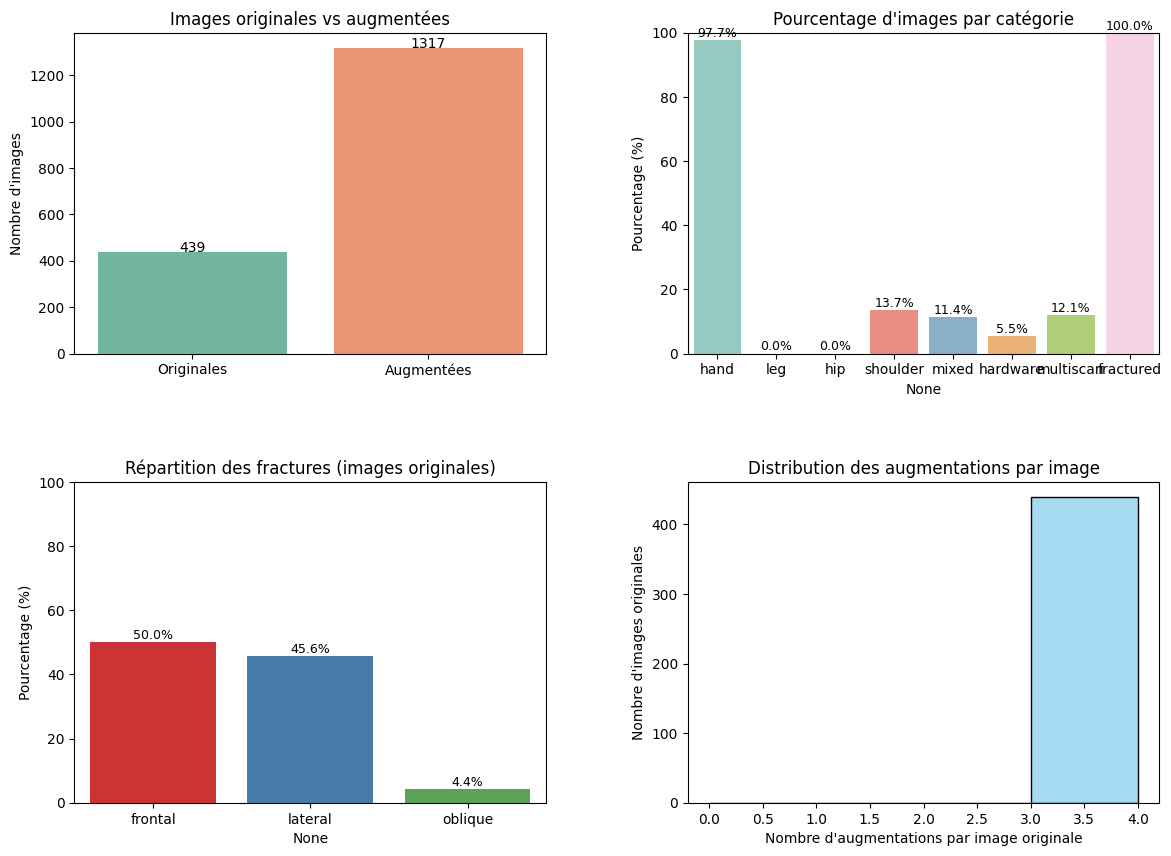

In [ ]:

################################################################### Charger le CSV final##################################################################
csv_file = '/content/drive/MyDrive/thesis doc/FracAtlas/member sup filtred/dataset_upper_limb_fractured_augmented.csv'
df = pd.read_csv(csv_file)
#################################################################### Ajouter colonne "is_augmented"########################################################
df['is_augmented'] = df['output_image'].str.contains('_aug')
########################################################### Extraire base_name pour compter augmentations##################################################
df['base_name'] = df['output_image'].str.replace(r'_aug\d+', '', regex=True).str.replace('.png','', regex=False)
################################################################### Colonnes pour pourcentage#############################################################
cols_meta = ['hand','leg','hip','shoulder','mixed','hardware','multiscan','fractured']
####################################################################### Répartition fractures###########################################################
cols_fracture = ['frontal','lateral','oblique']
###################################################################### Préparer figure multi-panel######################################################
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
################################################################ 1. Nombre d'images originales vs augmentées#################################################
nb_originales = (~df['is_augmented']).sum()
nb_augmentees = df['is_augmented'].sum()
sns.barplot(x=['Originales','Augmentées'], y=[nb_originales, nb_augmentees], palette='Set2', ax=axes[0,0])
axes[0,0].set_ylabel("Nombre d'images")
axes[0,0].set_title("Images originales vs augmentées")
for i, v in enumerate([nb_originales, nb_augmentees]):
    axes[0,0].text(i, v + 0.5, str(v), ha='center', fontsize=10)
################################################################ 2. Pourcentage des catégories#############################################################
percentages = df[cols_meta].mean() * 100  # moyenne = proportion
sns.barplot(x=percentages.index, y=percentages.values, palette='Set3', ax=axes[0,1])
axes[0,1].set_ylabel("Pourcentage (%)")
axes[0,1].set_title("Pourcentage d'images par catégorie")
axes[0,1].set_ylim(0, 100)
for i, v in enumerate(percentages.values):
    axes[0,1].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
######################################################## 3. Répartition des fractures (images originales)#########################################################
df_orig = df[~df['is_augmented']]
fracture_place_percent = df_orig[cols_fracture].sum() / df_orig[cols_fracture].sum().sum() * 100
sns.barplot(x=fracture_place_percent.index, y=fracture_place_percent.values, palette='Set1', ax=axes[1,0])
axes[1,0].set_ylabel("Pourcentage (%)")
axes[1,0].set_title("Répartition des fractures (images originales)")
axes[1,0].set_ylim(0, 100)
for i, v in enumerate(fracture_place_percent.values):
    axes[1,0].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)

######################################################## 4. Histogramme du nombre d'augmentations par image originale#############################################
augmentation_counts = df.groupby('base_name').size() - 1  # -1 pour l'originale
sns.histplot(augmentation_counts, bins=range(0, augmentation_counts.max()+2), color='skyblue', kde=False, ax=axes[1,1])
axes[1,1].set_xlabel("Nombre d'augmentations par image originale")
axes[1,1].set_ylabel("Nombre d'images originales")
axes[1,1].set_title("Distribution des augmentations par image")
plt.show()


***Note:***Le code principale sert à préparer et augmenter la partie selectionner de fractatlas pour membres sup seulement.
comment ?
1. Il sélectionne uniquement les membres supérieurs fracturés (main ou épaule, mais pas jambe ni hanche).

2. Il crée des masques de fracture à partir des annotations COCO.

3. Il génère des versions augmentées (rotations, retournements, luminosité, bruit, etc.).

4. Enfin, il sauvegarde les images et masques augmentés et crée un CSV avec les métadonnées mises à jour.


/tmp/ipython-input-2210258758.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=percentages.index, y=percentages.values, palette=palette)


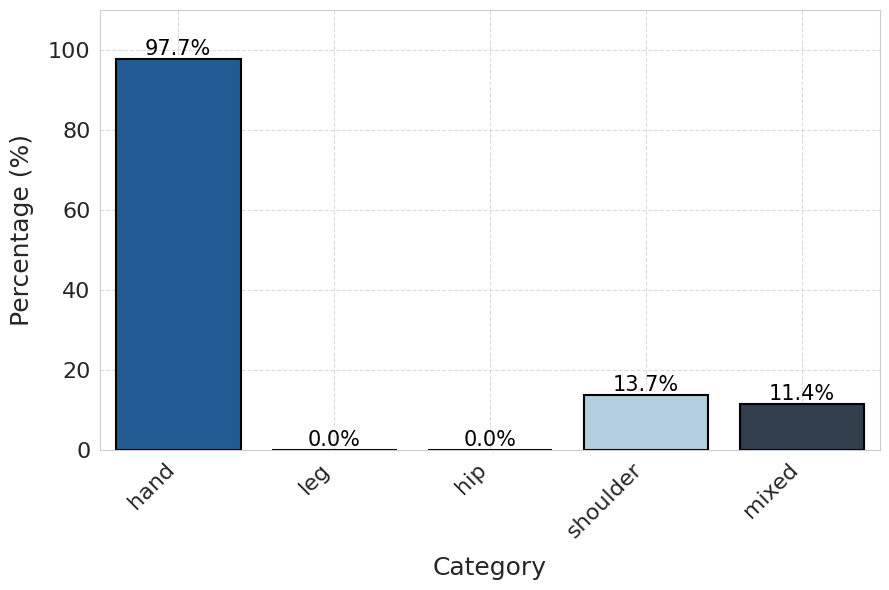

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================== Load CSV ====================
csv_file = '/content/drive/MyDrive/thesis doc/FracAtlas/member sup filtred/dataset_upper_limb_fractured_augmented.csv'
df = pd.read_csv(csv_file)

# ==================== Data preparation ====================
df['is_augmented'] = df['output_image'].str.contains('_aug')
df['base_name'] = df['output_image'].str.replace(r'_aug\d+', '', regex=True).str.replace('.png','', regex=False)

cols_meta = ['hand','leg','hip','shoulder','mixed']

sns.set_style("whitegrid")

# ---------- Percentages ----------
percentages = df[cols_meta].mean() * 100

# ---------- Palette ----------
original_palette = sns.color_palette("Blues_r", len(percentages))
palette = list(original_palette)

# Change color only for "mixed"
highlight_color = "#2C3E50"
for i, label in enumerate(percentages.index):
    if label == "mixed":
        palette[i] = highlight_color

# ---------- Plot ----------
plt.figure(figsize=(9,6))
ax = sns.barplot(x=percentages.index, y=percentages.values, palette=palette)

# Add black border around each bar
for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)

# Labels
plt.ylabel("Percentage (%)", fontsize=18, labelpad=10)
plt.xlabel("Category", fontsize=18, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)

# Grid
plt.ylim(0, 110)
plt.grid(True, linestyle='--', alpha=0.7)

# Percentage labels
for i, v in enumerate(percentages.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=15, color='black')

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/thesis doc/FracAtlas/member sup filtred/category_percentage_mixed_customcolor.pdf',
    format='pdf',
    dpi=300
)
plt.show()
